<a href="https://colab.research.google.com/github/ArnavK04/PH354-Assignments/blob/main/Kumar_Arnav_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Qusetion - 1**

**Q.1** Definition of the functions we transform are

**Square wave** - $
y_n =
\begin{cases}
1 & \text{if } n < \frac{N}{2} \\
-1 & \text{if } n \ge \frac{N}{2}
\end{cases}
$

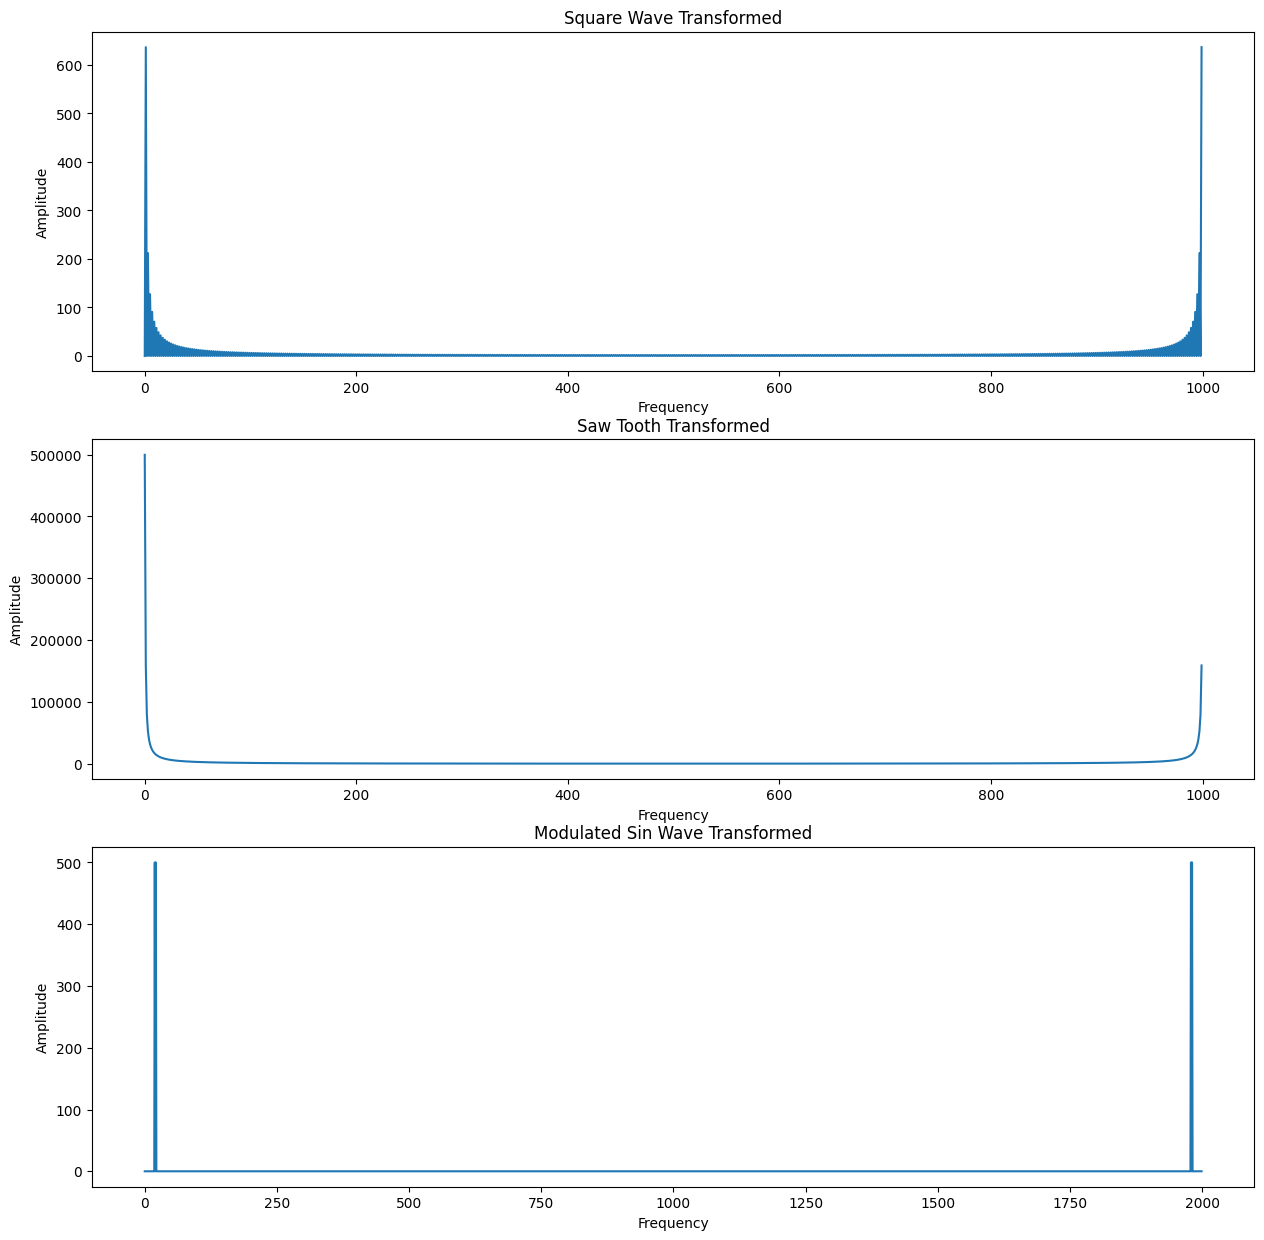

In [32]:
import numpy.fft
import math
import matplotlib.pyplot as plt
import numpy as np

N=1000
samples = np.arange(1000)

# square wave
square_wave = np.where(samples < N/2, 1, -1)
# saw tooth
saw_tooth = samples
# modulated sin wave. As given in the qeustion it has period 2N. We should take 2N samples to represent one full period.
samples2 = np.arange(2000)
modulated_sin_wave = np.sin(math.pi*samples2/N)*np.sin(20*math.pi*samples2/N)

# transforming them
square_wave_transformed = np.fft.fft(square_wave)
saw_tooth_transformed = np.fft.fft(saw_tooth)
modulated_sin_wave_transformed = np.fft.fft(modulated_sin_wave)

plt.figure(figsize=(15, 15))
plt.subplot(3, 1, 1)
plt.plot(np.abs(square_wave_transformed))
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.title('Square Wave Transformed')
#plt.xlim(0,50)
plt.subplot(3, 1, 2)
plt.plot(np.abs(saw_tooth_transformed))
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.title('Saw Tooth Transformed')
#plt.xlim(0,50)
plt.subplot(3, 1, 3)
plt.plot(np.abs(modulated_sin_wave_transformed))
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.title('Modulated Sin Wave Transformed')
#plt.xlim(0,50)
plt.show()


If we un-comment the xlimits on the plots, we can see that the square wave has only odd harmonics which decay fast. sawtooth wave has all harmonics which decay with increasing k. Modulated sine wave has only two principle frequencies.

# **Question - 2**

**Q.2 (a)**

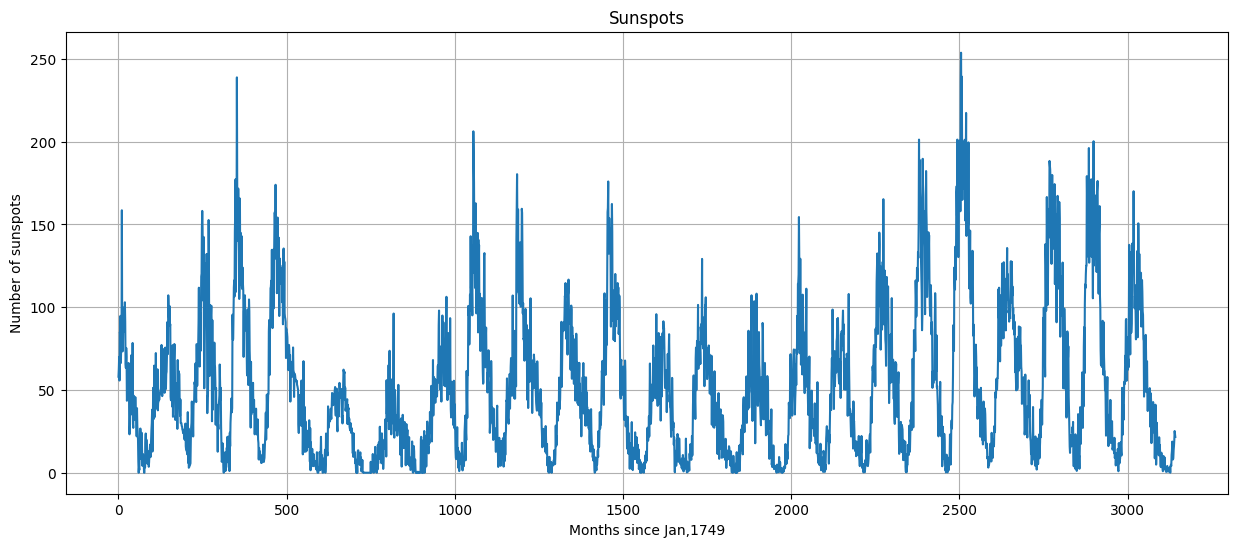

In [33]:
import requests
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/sunspots.txt"

response = requests.get(url)

sunspots_data = np.loadtxt(StringIO(response.text))

plt.figure(figsize = (15,6))
plt.plot(sunspots_data[:,0],sunspots_data[:,1])
plt.xlabel("Months since Jan,1749")
plt.ylabel("Number of sunspots")
plt.title("Sunspots")
plt.grid(which="both")
plt.show()

From the above plot, a rough estimate of the period of variations in the number of sunspots is 125 months.

**Q.2 (b) and (c)** Run part (a) first

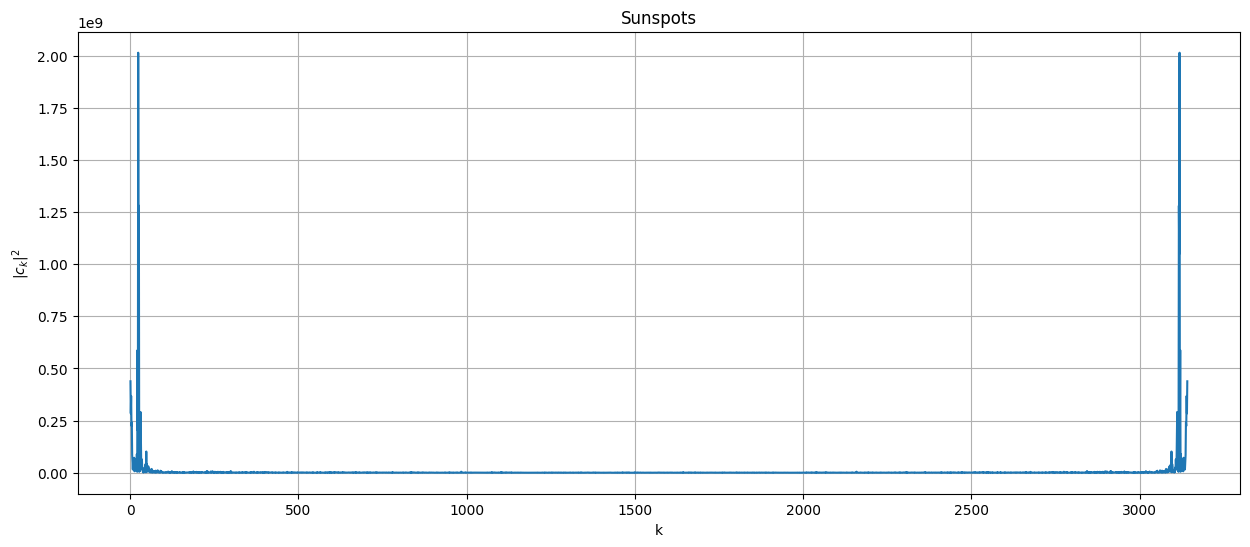


k with largest power is 23
most dominant period = 11.38768115942029 years or 136.65217391304347 months


In [34]:
import numpy.fft

k_modes = np.arange(len(sunspots_data[:,0]))

sunspots_transformed = np.fft.fft(sunspots_data[:,1])

plt.figure(figsize=(15,6))
plt.plot(k_modes[1:], (np.abs(sunspots_transformed[1:]))**2)    # ignoring the k=0 mode
plt.xlabel("k")
plt.ylabel(r"$|c_k|^2$")
plt.title("Sunspots")
plt.grid(which="both")
plt.show()
k_max = np.argmax(np.abs(sunspots_transformed[1:]))
print()
print(f"k with largest power is {k_max}")
print(f"most dominant period = {len(sunspots_data[:,1])/(12*k_max)} years or {len(sunspots_data[:,1])/(k_max)} months")

From above, we see that the most dominant period is around 137 months which is close to our rough estimate.

## **Question - 3**

**Q.3 (a)**

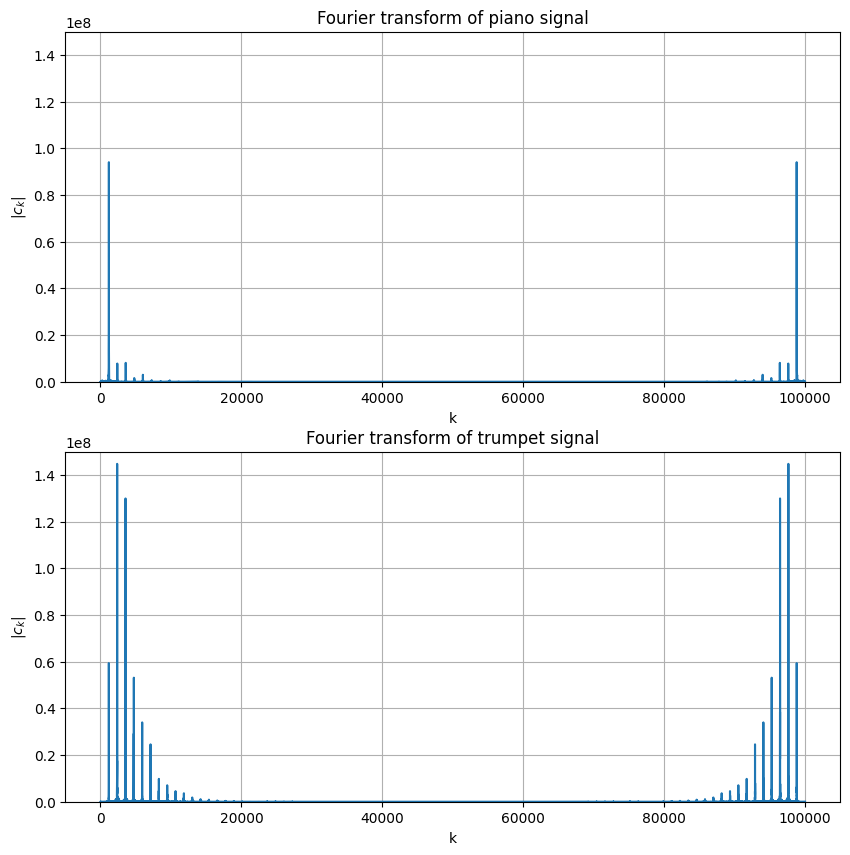

In [37]:
import requests
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/piano.txt"
response = requests.get(url)
piano_data = np.loadtxt(StringIO(response.text))

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/trumpet.txt"
response = requests.get(url)
trumpet_data = np.loadtxt(StringIO(response.text))

piano_transform = np.fft.fft(piano_data)
trumpet_transform = np.fft.fft(trumpet_data)

k_piano = np.arange(len(piano_data))
k_trumpet = np.arange(len(trumpet_data))

plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(k_piano[1:],np.abs(piano_transform[1:]))   # ignoring k=0 mode
plt.xlabel("k")
plt.ylabel(r"$|c_k|$")
plt.title("Fourier transform of piano signal")
plt.grid(which="both")
plt.ylim(0,1.5e8)
plt.subplot(2,1,2)
plt.plot(k_trumpet[1:],np.abs(trumpet_transform[1:]))
plt.xlabel("k")
plt.ylabel(r"$|c_k|$")
plt.title("Fourier transform of trumpet signal")
plt.grid(which="both")
plt.ylim(0,1.5e8)
plt.show()

We see that for trumpet, higher harmonic frequencies are more pronounced compared to a piano. This is because the trumpet produces sound by vibrating air columns while piano produces notes by striking a string. Higher harmonics make trumpets sound more brighter (sharper) while piano sounds mellower.

**Q.3 (b)** We know that if highest power k is $k$, sample rate is $f_s$ and the number of samples $N$, the time period corresponding to $k$ is

$T = \frac{sampling\ time}{k}$

$\Rightarrow \frac{1}{f} = \frac{N}{f_s k}$

$\Rightarrow f = \frac{f_sk}{N}$

In [38]:
k_pianomax = np.argmax(np.abs(piano_transform))
k_trumpetmax = np.argmax(np.abs(trumpet_transform))

f_max_piano = 44100*k_pianomax/len(piano_data)
f_max_trumpet = 44100*k_trumpetmax/len(trumpet_data)

print(f"Maximum frequency in piano signal is {f_max_piano} Hz")
print(f"Maximum frequency in trumpet signal is {f_max_trumpet} Hz")

Maximum frequency in piano signal is 524.79 Hz
Maximum frequency in trumpet signal is 1043.847 Hz


We see that both signals have the dominant frequencies which are multiples of $\approx 261$ Hz which is the note middle C. Therefore the note both intruments were playing was middle C.

# **Question - 4**

**Q.4 (a)**

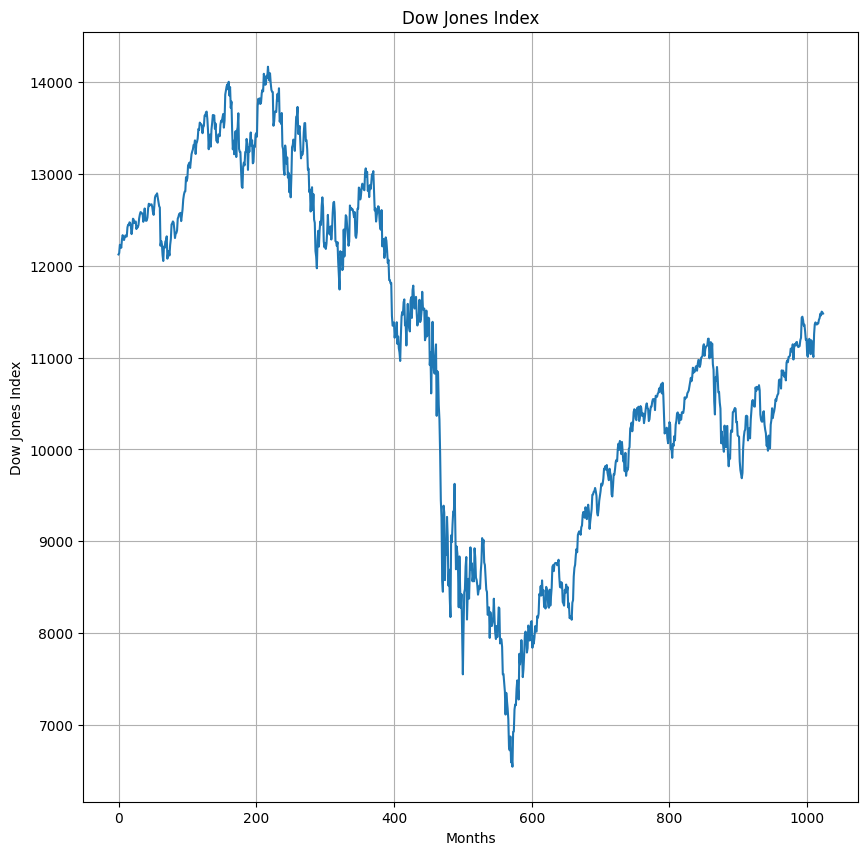

In [40]:
import requests
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/dow.txt"
response = requests.get(url)
dow_data = np.loadtxt(StringIO(response.text))

plt.figure(figsize=(10,10))
plt.plot(dow_data)
plt.xlabel("Months")
plt.ylabel("Dow Jones Index")
plt.title("Dow Jones Index")
plt.grid(which="both")
plt.show()

**Q.4 (b) and (c)**

In [42]:
dow_transformed = np.fft.rfft(dow_data)

length = len(dow_data)
partition = int(0.1*length)

dow_transformed[partition:] = np.zeros_like(dow_transformed[partition:])

**Q.4 (d)**

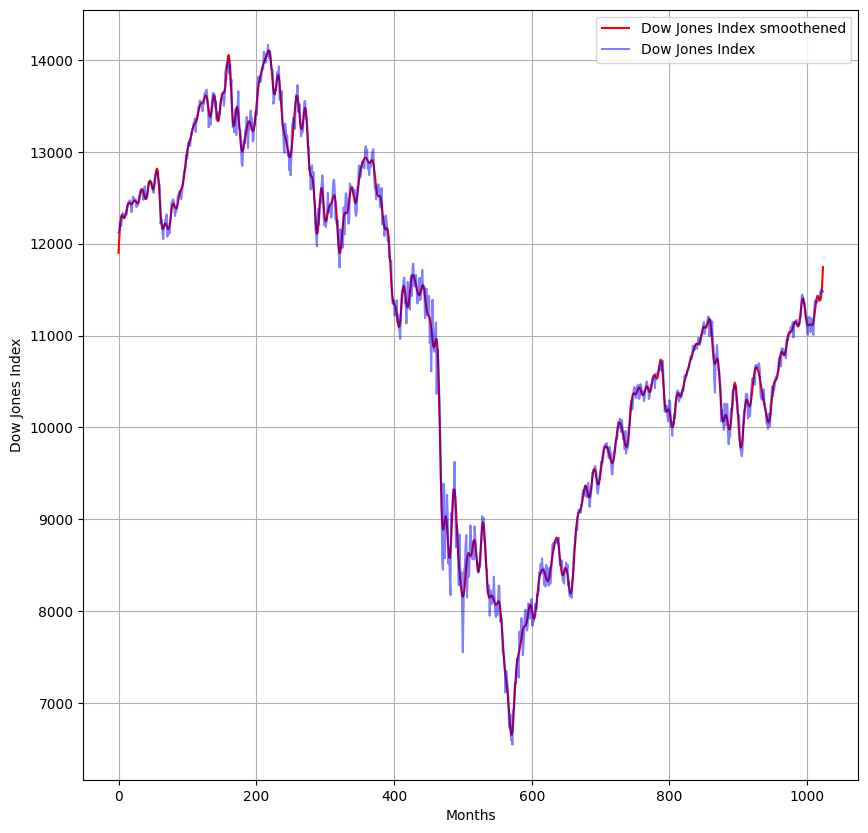

In [43]:
dow_inv_ft = np.fft.irfft(dow_transformed)

plt.figure(figsize=(10,10))
plt.plot(dow_inv_ft, label="Dow Jones Index smoothened", color = 'red')
plt.plot(dow_data, label="Dow Jones Index", color = 'blue', alpha = 0.5)
plt.legend()
plt.xlabel("Months")
plt.ylabel("Dow Jones Index")
plt.grid(which='both')
plt.show()

We see that the data becomes smooth after we filter the higher k-modes. This is expected since the higher k-modes introduce more frequent wiggles in the data and hence introduce noise. Removing them makes data less noisy.

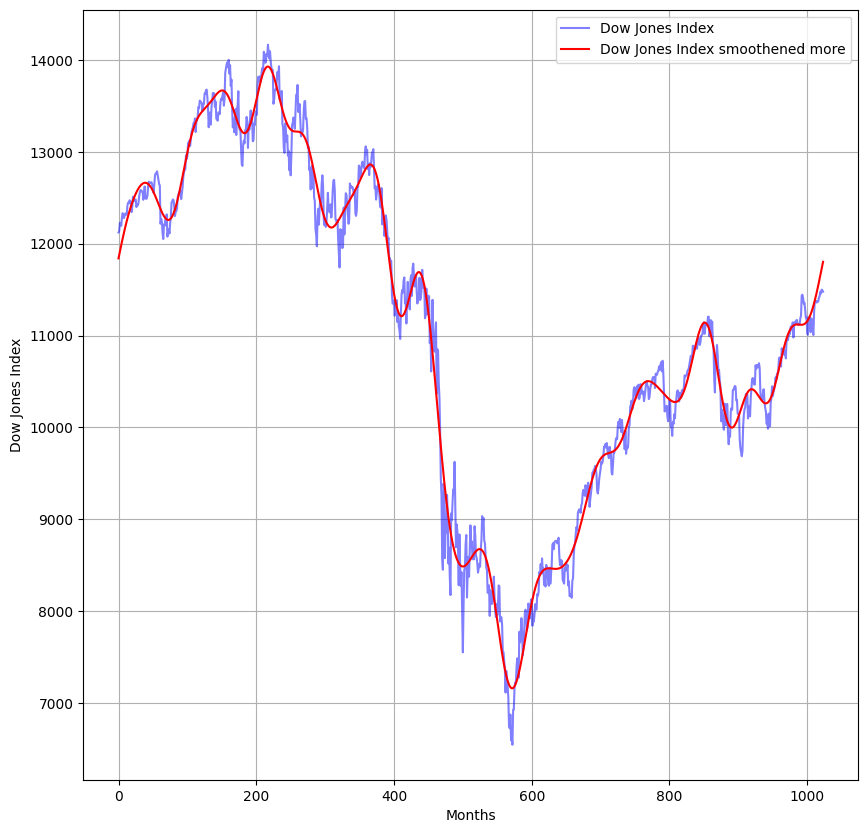

In [45]:
dow_transformed_new = np.fft.rfft(dow_data)

length = len(dow_data)
partition = int(0.02*length)

dow_transformed_new[partition:] = np.zeros_like(dow_transformed_new[partition:])

dow_inv_ft_new = np.fft.irfft(dow_transformed_new)

plt.figure(figsize=(10,10))
plt.plot(dow_data, label="Dow Jones Index", color = 'blue', alpha = 0.5)
plt.plot(dow_inv_ft_new, label="Dow Jones Index smoothened more", color = 'red')
plt.legend()
plt.xlabel("Months")
plt.ylabel("Dow Jones Index")
plt.grid(which='both')
plt.show()

We see that the data is smoothened even more. It looses more of the finer features.

**Smoothening a Square wave**

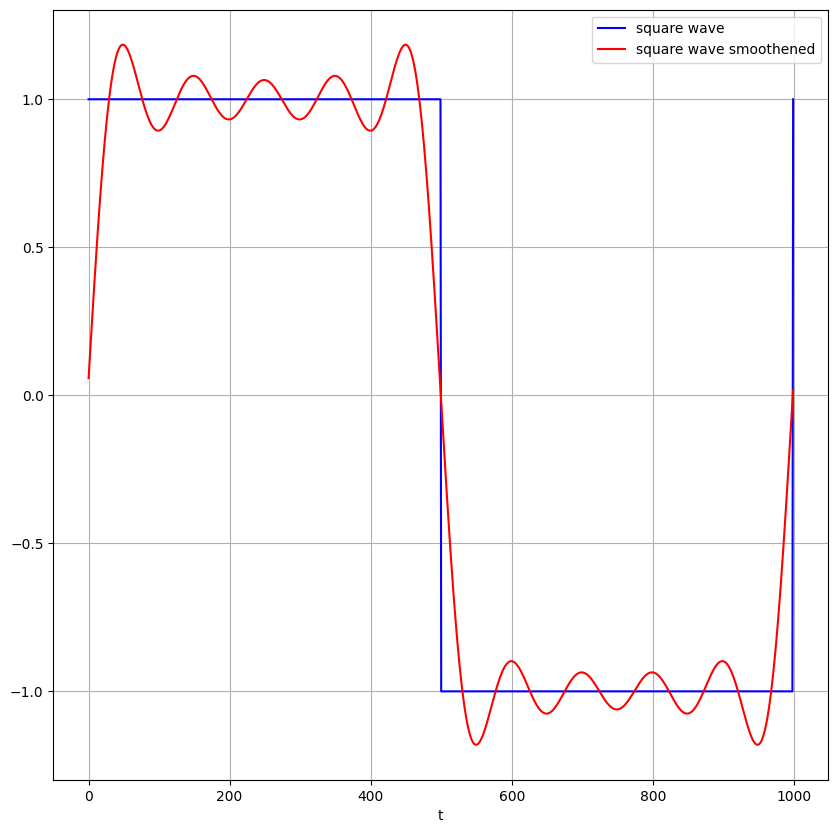

In [49]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000

def square_wave(t):
  if (int(2*t)%2 ==0):
    return 1
  else:
    return -1

x_data = np.linspace(0,1,1000)
square_wave_data = np.array([square_wave(t) for t in x_data])
square_wave_ft = np.fft.rfft(square_wave_data)
square_wave_ft[10:] = np.zeros_like(square_wave_ft[10:])
square_wave_inv_ft = np.fft.irfft(square_wave_ft)

plt.figure(figsize=(10,10))
plt.plot(square_wave_data, label='square wave', color = 'blue')
plt.plot(square_wave_inv_ft, label='square wave smoothened', color = 'red')
plt.legend()
plt.xlabel('t')
plt.grid(which='both')
plt.show()

We see that instead of getting more smooth, the data has more wiggles now. This is because the square wave is an infinite harmonic series. When we remove the high k contributions, the sum is now a finite sum of sines and cosines, which produced wiggles.

# **Question - 5**

**Q.5 (a)**

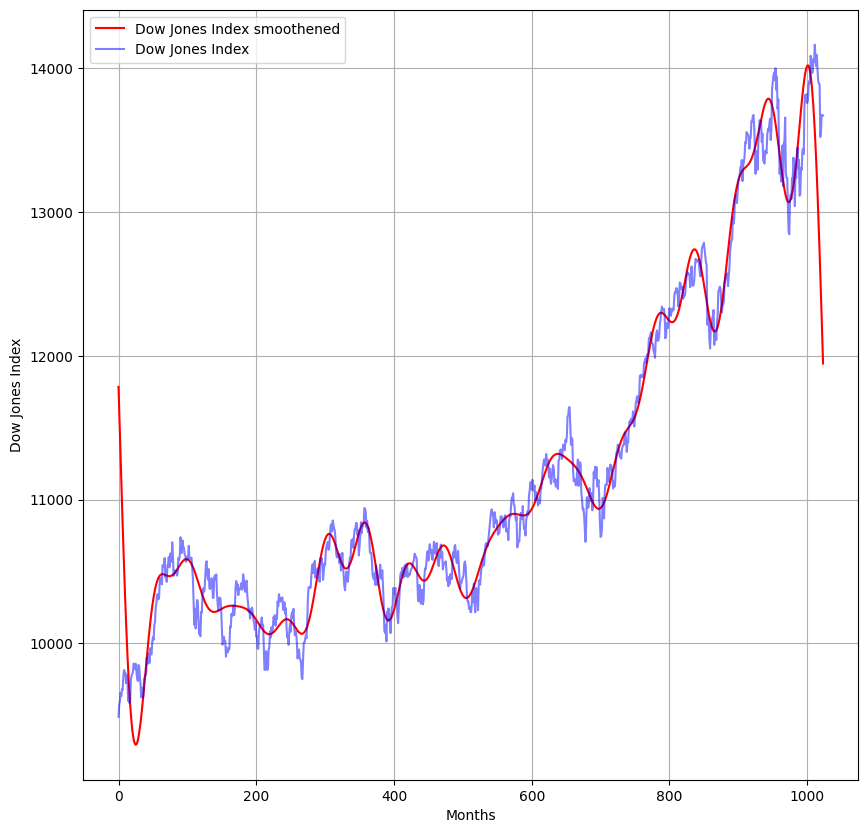

In [50]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/dow2.txt"
response = requests.get(url)
dow2_data = np.loadtxt(StringIO(response.text))

dow2_transformed = np.fft.rfft(dow2_data)

length = len(dow2_data)
partition = int(0.02*length)

dow2_transformed[partition:] = np.zeros_like(dow2_transformed[partition:])

dow2_inv_ft = np.fft.irfft(dow2_transformed)

plt.figure(figsize=(10,10))
plt.plot(dow2_inv_ft, label="Dow Jones Index smoothened", color = 'red')
plt.plot(dow2_data, label="Dow Jones Index", color = 'blue', alpha = 0.5)
plt.legend()
plt.xlabel("Months")
plt.ylabel("Dow Jones Index")
plt.grid(which='both')
plt.show()

**Q.5 (b)**

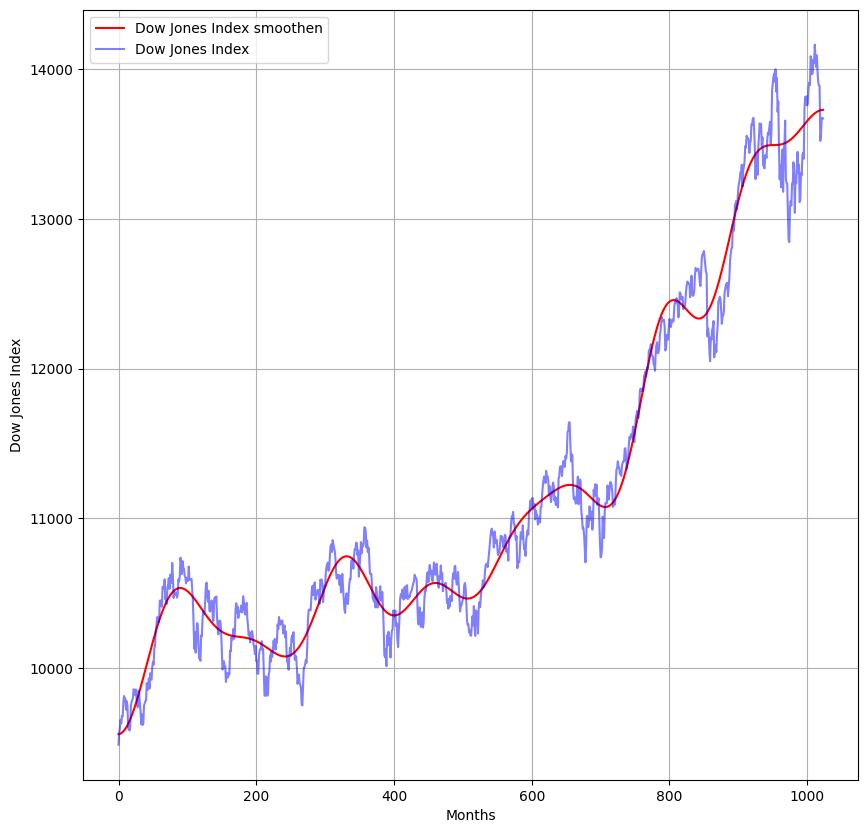

In [52]:
from scipy.fft import dct, idct

dow2_dct = dct(dow2_data)

length = len(dow2_data)
partition = int(0.02*length)
dow2_dct[partition:] = np.zeros_like(dow2_dct[partition:])

dow2_idct = idct(dow2_dct)

plt.figure(figsize=(10,10))
plt.plot(dow2_idct, label="Dow Jones Index smoothen", color = 'red')
plt.plot(dow2_data, label="Dow Jones Index", color = 'blue', alpha = 0.5)
plt.legend()
plt.xlabel("Months")
plt.ylabel("Dow Jones Index")
plt.grid(which='both')
plt.show()

# **Question - 6**

In [53]:
import numpy as np

def manual_fft(x):
    N = len(x)

    if N == 1:
        return x

    # splitting even and odd
    even = manual_fft(x[::2])
    odd  = manual_fft(x[1::2])

    factor = np.exp(-2j*np.pi*np.arange(N)/N)

    c = np.zeros(N, dtype=complex)

    for k in range(N//2):
        c[k] = even[k] + factor[k]*odd[k]
        c[k + N//2] = even[k] - factor[k]*odd[k]

    return c

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


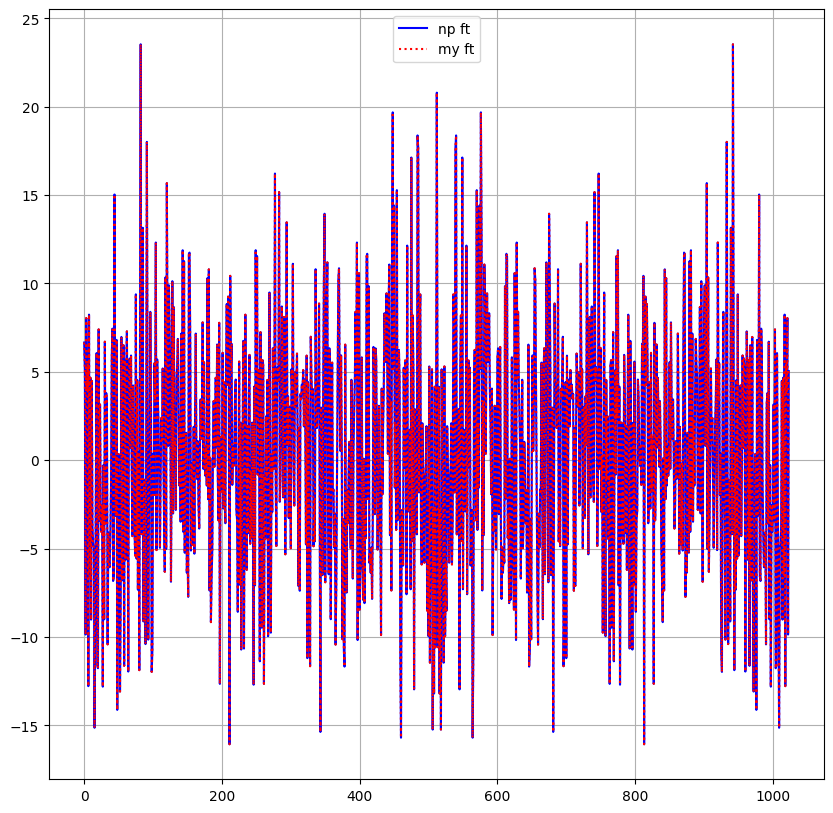

True


In [59]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/pitch.txt"

response = requests.get(url)
data = np.loadtxt(StringIO(response.text))

# ensuring that the length is power of 2
N = 2**int(np.log2(len(data)))
data = data[:N]

# compute transforms
my_ft = manual_fft(data)
np_ft = np.fft.fft(data)

plt.figure(figsize=(10,10))
plt.plot(np_ft,label='np ft', linestyle='-', color='blue', alpha=1)
plt.plot(my_ft,label='my ft', linestyle=':', color='red')
plt.legend()
plt.grid(which='both')
plt.show()

# check if all elements are same
print(np.allclose(my_ft, np_ft))

# **Question - 7**

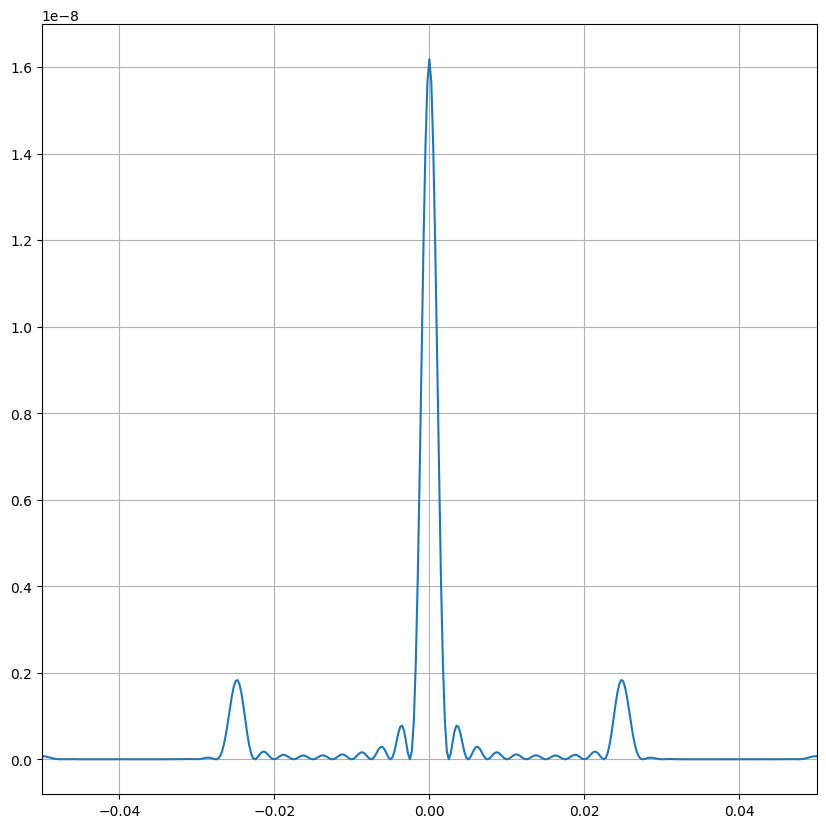

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import math

w = 200e-6
W = 10*w
lambd = 500e-9
f = 1.
scrn_width = 0.1

def transm_func(u):
  alpha = math.pi/(20e-6)
  return math.sin(alpha*u)*math.sin(alpha*u)

def y_func(u):
  return math.sqrt(transm_func(u))

N = 1000
u = np.linspace(-w/2,w/2,N)
y = np.vectorize(y_func)(u)
# padding y with zeros on both sides. 4.5N zeros on each side
y = np.concatenate((np.zeros(int(4.5*N)),y,np.zeros(int(4.5*N))))
N = len(y)
k = np.arange(N)

y_ft = np.fft.fft(y)
y_ft = np.fft.fftshift(y_ft)      # shifting the the frequencies so that 0 is in the centre. c_{N-k} = c_{-k}
I_k = ((W/N)**2)*((np.abs(y_ft))**2)
x_k = lambd*f*(k-N//2)/W          # shifting x as well so that x = 0 is in the centre

plt.figure(figsize=(10,10))
plt.plot(x_k, I_k, label='Intensity')
plt.xlim(-0.05,0.05)
plt.grid(which='both')
plt.show()

# **Question - 8**

**Q.8 (a)**

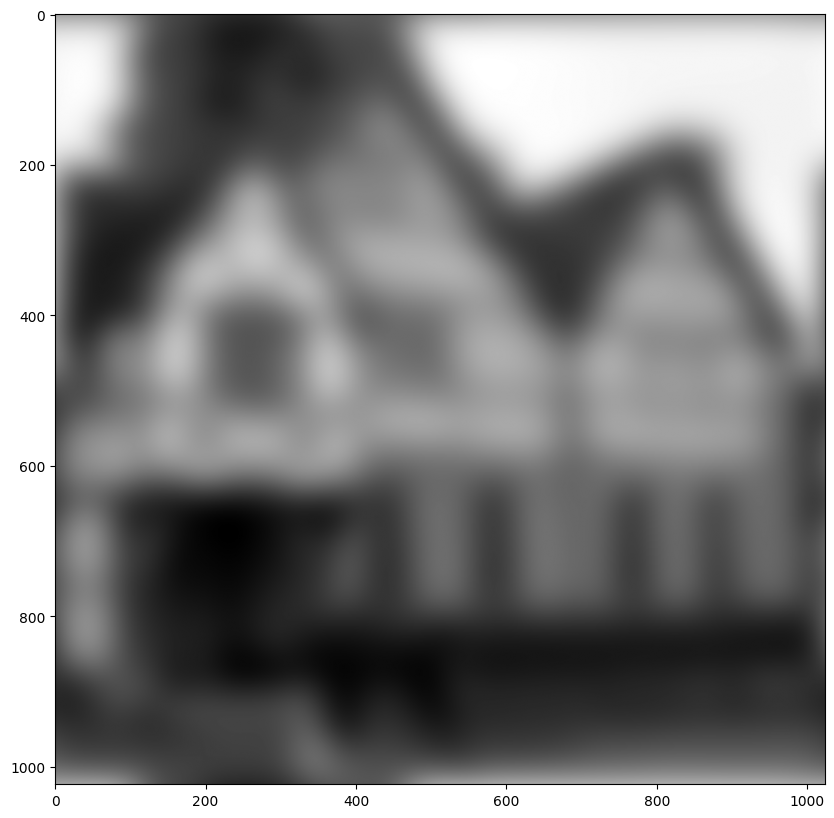

In [61]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/blur.txt"
response = requests.get(url)
blur_data = np.loadtxt(StringIO(response.text))

plt.figure(figsize=(10,10))
plt.imshow(blur_data, cmap='gray')
plt.show()

**Q.8 (b)**

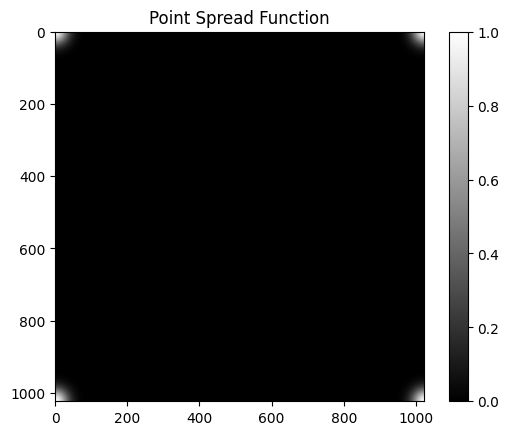

In [67]:
N = len(blur_data[0])
sigma = 25

psf = np.zeros((N,N))

for i in range(N):
    for j in range(N):

        x = i if i < N//2 else i - N
        y = j if j < N//2 else j - N

        psf[i,j] = np.exp(-(x*x + y*y)/(2*sigma*sigma))

plt.imshow(psf, cmap = 'gray')
plt.colorbar()
plt.title("Point Spread Function")
plt.show()

**Q.8 (c)** Combining the above two programs

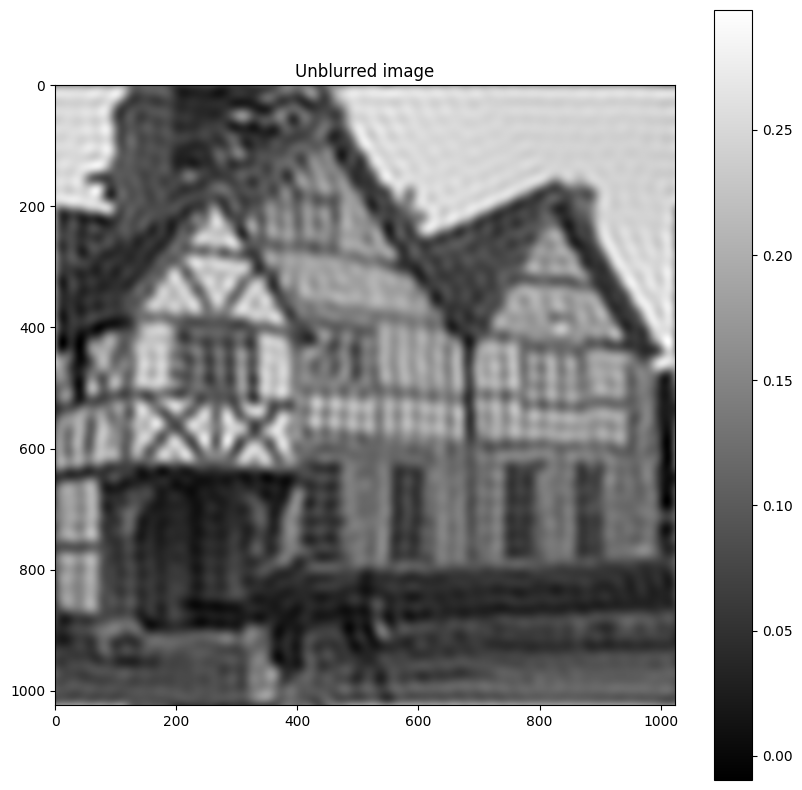

In [70]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

url = "https://raw.githubusercontent.com/ArnavK04/PH354-Assignments/refs/heads/main/blur.txt"
response = requests.get(url)
blur_data = np.loadtxt(StringIO(response.text))

N = len(blur_data[0])
sigma = 25

psf = np.zeros((N,N))

for i in range(N):
    for j in range(N):

        x = i if i < N//2 else i - N
        y = j if j < N//2 else j - N

        psf[i,j] = np.exp(-(x*x + y*y)/(2*sigma*sigma))

blur_data_ft = np.fft.rfft2(blur_data)
psf_ft = np.fft.rfft2(psf)

image_ft = np.divide(blur_data_ft, psf_ft,out = blur_data_ft, where=psf_ft>1e-3)
image = np.fft.irfft2(image_ft)

plt.figure(figsize=(10,10))
plt.imshow(image, cmap='gray')
plt.colorbar()
plt.title('Unblurred image')
plt.show()

**Q.8 (d)**The fact that these zeros in the fourier transform of the point spread function exist limits us to sharpen our original image perfectly. We we divide by these coefficients, the corresponding noise is greatly amplified. So, we need to leave out these coefficients always. This limits our ability to deblur a photo.